In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from sklearn.cluster import KMeans

IMAGE_PATH = Path("image.png")
OUTPUT_PATH = Path("image_dealiased.png")
N_COLORS = 11
BACKGROUND_DELTA_THRESHOLD = 10.0
MIN_STRONG_DELTA = 35.0
MIN_ALPHA = 0.18
SEED_ALPHA = 0.45
RANDOM_STATE = 7


def load_rgb_image(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.uint8)


def merge_similar_colors(colors: np.ndarray, min_distance: float = 18.0) -> np.ndarray:
    kept: list[np.ndarray] = []
    for color in colors:
        if not kept:
            kept.append(color)
            continue

        distances = [np.linalg.norm(color.astype(np.float32) - other.astype(np.float32)) for other in kept]
        if min(distances) >= min_distance:
            kept.append(color)

    return np.asarray(kept, dtype=np.uint8)


def discover_palette(pixels: np.ndarray, n_colors: int) -> np.ndarray:
    flat_pixels = pixels.reshape(-1, 3).astype(np.float32)
    delta_from_white = 255.0 - flat_pixels
    delta_strength = np.linalg.norm(delta_from_white, axis=1)

    strong_pixels = delta_from_white[delta_strength > MIN_STRONG_DELTA]
    if len(strong_pixels) < n_colors:
        raise ValueError("Not enough colored pixels to infer the palette.")

    normalized = strong_pixels / np.linalg.norm(strong_pixels, axis=1, keepdims=True)
    model = KMeans(n_clusters=n_colors, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(normalized)

    palette = []
    for cluster_index in range(n_colors):
        cluster = strong_pixels[labels == cluster_index]
        representative_delta = np.percentile(cluster, 98, axis=0)
        representative_color = np.clip(255.0 - representative_delta, 0, 255).round().astype(np.uint8)
        palette.append(representative_color)

    palette = np.asarray(palette, dtype=np.uint8)
    palette = palette[np.argsort(np.sum(255 - palette, axis=1))]
    return merge_similar_colors(palette)


def classify_pixels(pixels: np.ndarray, palette: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    flat_pixels = pixels.reshape(-1, 3).astype(np.float32)
    delta_from_white = 255.0 - flat_pixels
    delta_strength = np.linalg.norm(delta_from_white, axis=1)

    palette_delta = 255.0 - palette.astype(np.float32)
    denom = np.sum(palette_delta * palette_delta, axis=1)

    alpha = (delta_from_white @ palette_delta.T) / denom
    alpha = np.clip(alpha, 0.0, 1.0)

    reconstructions = 255.0 - alpha[:, :, None] * palette_delta[None, :, :]
    reconstruction_error = np.linalg.norm(flat_pixels[:, None, :] - reconstructions, axis=2)
    best_match = reconstruction_error.argmin(axis=1)
    best_alpha = alpha[np.arange(len(flat_pixels)), best_match]

    foreground_mask = (delta_strength >= BACKGROUND_DELTA_THRESHOLD) & (best_alpha >= MIN_ALPHA)
    return best_match, best_alpha, foreground_mask


def hard_dealias(pixels: np.ndarray, palette: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    height, width = pixels.shape[:2]
    best_match, best_alpha, foreground_mask = classify_pixels(pixels, palette)

    seed_mask = foreground_mask & (best_alpha >= SEED_ALPHA)
    labels = np.full(height * width, -1, dtype=np.int32)
    labels[seed_mask] = best_match[seed_mask]

    foreground_2d = foreground_mask.reshape(height, width)
    seed_2d = seed_mask.reshape(height, width)
    labels_2d = labels.reshape(height, width)

    if seed_2d.any():
        _, nearest_seed_indices = distance_transform_edt(~seed_2d, return_indices=True)
        nearest_rows, nearest_cols = nearest_seed_indices
        propagated_labels = labels_2d[nearest_rows, nearest_cols]
        final_labels = np.where(foreground_2d, propagated_labels, -1)
    else:
        final_labels = np.where(foreground_2d, best_match.reshape(height, width), -1)

    result = np.full((height, width, 3), 255, dtype=np.uint8)
    colored_mask = final_labels >= 0
    result[colored_mask] = palette[final_labels[colored_mask]]

    return result, best_alpha.reshape(height, width)


def build_palette_strip(colors: np.ndarray, swatch_width: int = 80, swatch_height: int = 60) -> np.ndarray:
    strip = np.zeros((swatch_height, swatch_width * len(colors), 3), dtype=np.uint8)
    for index, color in enumerate(colors):
        strip[:, index * swatch_width : (index + 1) * swatch_width] = color
    return strip


pixels = load_rgb_image(IMAGE_PATH)
palette = discover_palette(pixels, n_colors=N_COLORS)
dealiased, alpha = hard_dealias(pixels, palette)

Image.fromarray(dealiased).save(OUTPUT_PATH)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(pixels)
axes[0].set_title("Original")
axes[1].imshow(dealiased)
axes[1].set_title("Hard de-aliased")
axes[2].imshow(build_palette_strip(palette))
axes[2].set_title("Recovered palette")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print(f"Saved: {OUTPUT_PATH.resolve()}")
print("Palette:")
for color in palette:
    print(tuple(int(channel) for channel in color))
print(f"Foreground pixels kept: {(alpha >= MIN_ALPHA).sum():,}")

FileNotFoundError: [Errno 2] No such file or directory: 'image.png'

## Layer Separation Pipeline (from image_processing_service)
This section mirrors the production logic used by split_sketch_by_color so you can inspect and iterate in-notebook.
- Palette discovery from anti-white deltas
- Hard de-aliasing with seed propagation
- Per-color transparent PNG layer export as base64 data URLs

In [ ]:
import base64
import io

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
from sklearn.cluster import KMeans

_N_COLORS = 14
_BACKGROUND_DELTA_THRESHOLD = 25.0
_MIN_STRONG_DELTA = 40.0
_MIN_ALPHA = 0.55
_SEED_ALPHA = 0.72
_RANDOM_STATE = 7
_ALIASED_COSINE_THRESHOLD = 0.97
_ALIASED_MAX_STRENGTH_RATIO = 0.65


def _merge_similar_colors(colors: np.ndarray, min_distance: float = 18.0) -> np.ndarray:
    kept: list[np.ndarray] = []
    for color in colors:
        if not kept:
            kept.append(color)
            continue
        distances = [np.linalg.norm(color.astype(np.float32) - other.astype(np.float32)) for other in kept]
        if min(distances) >= min_distance:
            kept.append(color)
    return np.asarray(kept, dtype=np.uint8)


def _remove_aliased_palette_colors(colors: np.ndarray) -> np.ndarray:
    deltas = 255.0 - colors.astype(np.float32)
    strengths = np.linalg.norm(deltas, axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        normalized = deltas / strengths[:, None]

    cosine_sim = normalized @ normalized.T
    keep = np.ones(len(colors), dtype=bool)

    for i in range(len(colors)):
        if not keep[i]:
            continue
        for j in range(i + 1, len(colors)):
            if not keep[j]:
                continue
            if cosine_sim[i, j] < _ALIASED_COSINE_THRESHOLD:
                continue
            ratio = min(strengths[i], strengths[j]) / max(strengths[i], strengths[j])
            if ratio > _ALIASED_MAX_STRENGTH_RATIO:
                continue
            if strengths[i] >= strengths[j]:
                keep[j] = False
            else:
                keep[i] = False
                break

    return colors[keep]


def _discover_palette(pixels: np.ndarray) -> np.ndarray:
    flat_pixels = pixels.reshape(-1, 3).astype(np.float32)
    delta_from_white = 255.0 - flat_pixels
    delta_strength = np.linalg.norm(delta_from_white, axis=1)

    strong_pixels = delta_from_white[delta_strength > _MIN_STRONG_DELTA]
    if len(strong_pixels) < _N_COLORS:
        raise ValueError("Not enough colored pixels to infer the palette.")

    normalized = strong_pixels / np.linalg.norm(strong_pixels, axis=1, keepdims=True)
    model = KMeans(n_clusters=_N_COLORS, n_init=20, random_state=_RANDOM_STATE)
    labels = model.fit_predict(normalized)

    palette = []
    for cluster_index in range(_N_COLORS):
        cluster = strong_pixels[labels == cluster_index]
        representative_delta = np.percentile(cluster, 98, axis=0)
        representative_color = np.clip(255.0 - representative_delta, 0, 255).round().astype(np.uint8)
        palette.append(representative_color)

    palette = np.asarray(palette, dtype=np.uint8)
    palette = palette[np.argsort(np.sum(255 - palette, axis=1))]
    palette = _merge_similar_colors(palette)
    palette = _remove_aliased_palette_colors(palette)
    return palette


def _classify_pixels(pixels: np.ndarray, palette: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    flat_pixels = pixels.reshape(-1, 3).astype(np.float32)
    delta_from_white = 255.0 - flat_pixels
    delta_strength = np.linalg.norm(delta_from_white, axis=1)

    palette_delta = 255.0 - palette.astype(np.float32)
    denom = np.sum(palette_delta * palette_delta, axis=1)

    alpha = (delta_from_white @ palette_delta.T) / denom
    alpha = np.clip(alpha, 0.0, 1.0)

    reconstructions = 255.0 - alpha[:, :, None] * palette_delta[None, :, :]
    reconstruction_error = np.linalg.norm(flat_pixels[:, None, :] - reconstructions, axis=2)
    best_match = reconstruction_error.argmin(axis=1)
    best_alpha = alpha[np.arange(len(flat_pixels)), best_match]

    foreground_mask = (delta_strength >= _BACKGROUND_DELTA_THRESHOLD) & (best_alpha >= _MIN_ALPHA)
    return best_match, best_alpha, foreground_mask


def _hard_dealias(pixels: np.ndarray, palette: np.ndarray) -> np.ndarray:
    height, width = pixels.shape[:2]
    best_match, best_alpha, foreground_mask = _classify_pixels(pixels, palette)

    seed_mask = foreground_mask & (best_alpha >= _SEED_ALPHA)
    labels = np.full(height * width, -1, dtype=np.int32)
    labels[seed_mask] = best_match[seed_mask]

    foreground_2d = foreground_mask.reshape(height, width)
    seed_2d = seed_mask.reshape(height, width)
    labels_2d = labels.reshape(height, width)

    if seed_2d.any():
        _, nearest_seed_indices = distance_transform_edt(~seed_2d, return_indices=True)
        nearest_rows, nearest_cols = nearest_seed_indices
        propagated_labels = labels_2d[nearest_rows, nearest_cols]
        final_labels = np.where(foreground_2d, propagated_labels, -1)
    else:
        final_labels = np.where(foreground_2d, best_match.reshape(height, width), -1)

    result = np.full((height, width, 3), 255, dtype=np.uint8)
    colored_mask = final_labels >= 0
    result[colored_mask] = palette[final_labels[colored_mask]]
    return result


def split_sketch_by_color(img: Image.Image) -> list[str]:
    pixels = np.asarray(img.convert("RGB"), dtype=np.uint8)
    palette = _discover_palette(pixels)
    dealiased = _hard_dealias(pixels, palette)

    h, w = dealiased.shape[:2]
    data_urls: list[str] = []

    for color in palette:
        mask = np.all(dealiased == color, axis=2)
        layer = np.zeros((h, w, 4), dtype=np.uint8)
        layer[mask] = [0, 0, 0, 255]

        layer_img = Image.fromarray(layer, mode="RGBA")
        buf = io.BytesIO()
        layer_img.save(buf, format="PNG")
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
        data_urls.append(f"data:image/png;base64,{b64}")

    return data_urls

Separated layers (raw): 14
Separated layers (merged): 10
Image size: 640 x 413
Similarity threshold: 0.65
Proximity radius: 1 px
Merged groups (1-based indices):
[1, 6]
[2, 3]
[4]
[5, 14]
[7, 12]
[8]
[9]
[10]
[11]
[13]

Pairwise similarity matrix (max(IoU, containment, proximity)):
[[1.    0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.
  0.    0.   ]
 [0.    1.    0.656 0.    0.    0.    0.    0.    0.002 0.    0.    0.004
  0.    0.   ]
 [0.    0.656 1.    0.008 0.    0.    0.008 0.    0.072 0.    0.    0.008
  0.    0.   ]
 [0.    0.    0.008 1.    0.    0.    0.    0.    0.    0.    0.    0.
  0.002 0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.
  0.    1.   ]
 [1.    0.    0.    0.    0.    1.    0.    0.    0.    0.012 0.    0.
  0.    0.   ]
 [0.    0.    0.008 0.    0.    0.    1.    0.    0.033 0.    0.    0.975
  0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.024 0.    0.    0.
  0.214 0.131]
 [0.    0.002 0.072 

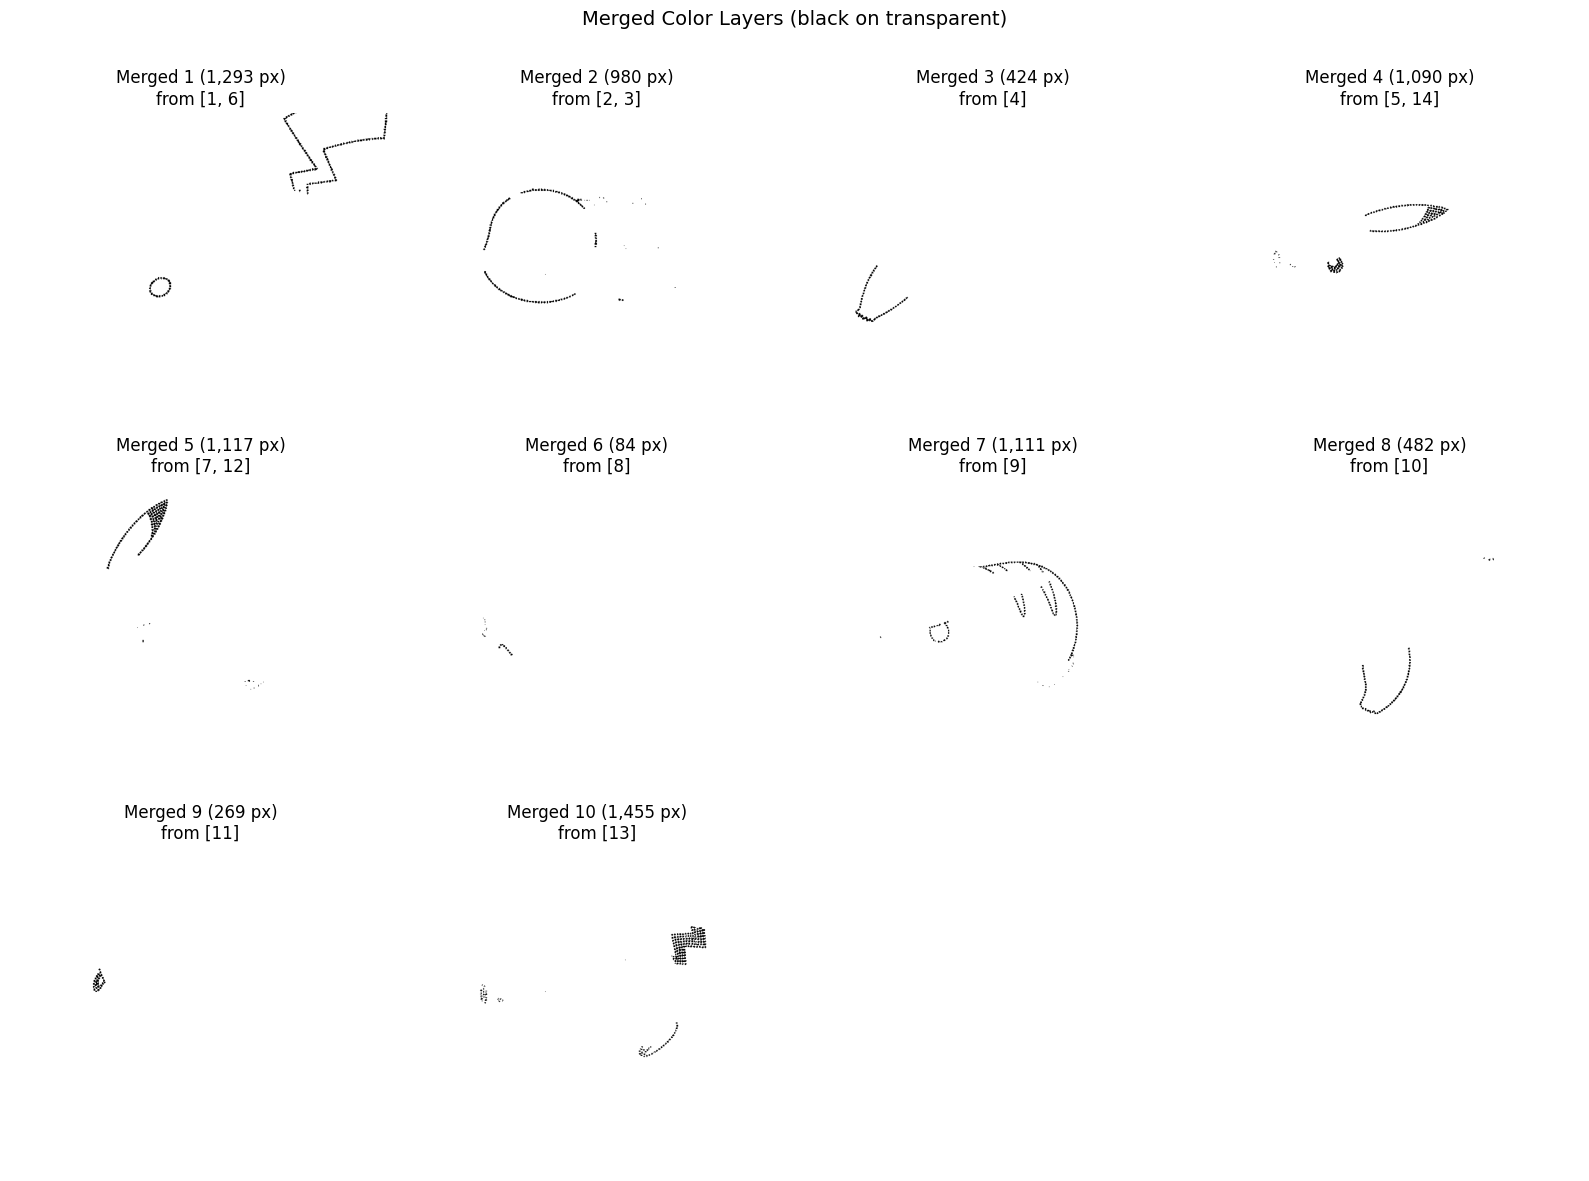

In [ ]:
from math import ceil

from scipy.ndimage import binary_dilation

TEST_IMAGE_PATH = "image.png"
SIMILARITY_THRESHOLD = 0.65
PROXIMITY_RADIUS = 1


def _decode_layer_data_url(data_url: str) -> np.ndarray:
    _, payload = data_url.split(",", 1)
    layer_bytes = base64.b64decode(payload)
    return np.asarray(Image.open(io.BytesIO(layer_bytes)).convert("RGBA"), dtype=np.uint8)


def _layer_to_mask(layer: np.ndarray) -> np.ndarray:
    return layer[..., 3] > 0


def _mask_similarity(mask_a: np.ndarray, mask_b: np.ndarray, proximity_radius: int = 1) -> float:
    area_a = mask_a.sum()
    area_b = mask_b.sum()
    if area_a == 0 or area_b == 0:
        return 0.0

    overlap = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    iou = overlap / max(union, 1)

    # Containment catches true overlap duplicates.
    containment = overlap / max(min(area_a, area_b), 1)

    # Proximity score catches anti-aliased duplicates shifted by ~1px.
    if proximity_radius > 0:
        structure = np.ones((2 * proximity_radius + 1, 2 * proximity_radius + 1), dtype=bool)
        a_near_b = np.logical_and(mask_a, binary_dilation(mask_b, structure=structure)).sum() / area_a
        b_near_a = np.logical_and(mask_b, binary_dilation(mask_a, structure=structure)).sum() / area_b
        proximity = max(a_near_b, b_near_a)
    else:
        proximity = 0.0

    return max(iou, containment, proximity)


def _build_merged_layers(layers: list[np.ndarray], similarity_threshold: float) -> tuple[list[np.ndarray], list[list[int]], np.ndarray]:
    masks = [_layer_to_mask(layer) for layer in layers]
    n = len(masks)
    parent = list(range(n))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    similarity_matrix = np.zeros((n, n), dtype=np.float32)

    # n*n pairwise pass: compare every layer with every other layer.
    for i in range(n):
        similarity_matrix[i, i] = 1.0
        for j in range(i + 1, n):
            score = _mask_similarity(masks[i], masks[j], proximity_radius=PROXIMITY_RADIUS)
            similarity_matrix[i, j] = score
            similarity_matrix[j, i] = score
            if score >= similarity_threshold:
                union(i, j)

    groups: dict[int, list[int]] = {}
    for idx in range(n):
        root = find(idx)
        groups.setdefault(root, []).append(idx)

    merged_layers: list[np.ndarray] = []
    merged_groups: list[list[int]] = []
    h, w = layers[0].shape[:2]
    for members in groups.values():
        merged_mask = np.zeros((h, w), dtype=bool)
        for m in members:
            merged_mask |= masks[m]

        merged = np.zeros((h, w, 4), dtype=np.uint8)
        merged[merged_mask] = [0, 0, 0, 255]
        merged_layers.append(merged)
        merged_groups.append(members)

    return merged_layers, merged_groups, similarity_matrix


img = Image.open(TEST_IMAGE_PATH)
layer_urls = split_sketch_by_color(img)
layer_rgba = [_decode_layer_data_url(url) for url in layer_urls]

merged_layers, merged_groups, similarity_matrix = _build_merged_layers(
    layer_rgba,
    similarity_threshold=SIMILARITY_THRESHOLD,
 )

print(f"Separated layers (raw): {len(layer_rgba)}")
print(f"Separated layers (merged): {len(merged_layers)}")
print(f"Image size: {img.size[0]} x {img.size[1]}")
print(f"Similarity threshold: {SIMILARITY_THRESHOLD:.2f}")
print(f"Proximity radius: {PROXIMITY_RADIUS} px")

if len(merged_layers) != len(layer_rgba):
    print("Merged groups (1-based indices):")
    for group in merged_groups:
        print([g + 1 for g in group])
else:
    print("No groups exceeded similarity threshold.")

if len(layer_rgba) <= 20:
    print("\nPairwise similarity matrix (max(IoU, containment, proximity)):")
    print(np.round(similarity_matrix, 3))

cols = 4
rows = ceil(len(merged_layers) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).reshape(rows, cols)

for i, layer in enumerate(merged_layers):
    r, c = divmod(i, cols)
    nonzero = int((layer[..., 3] > 0).sum())
    original_members = ", ".join(str(idx + 1) for idx in merged_groups[i])
    axes[r, c].imshow(layer)
    axes[r, c].set_title(f"Merged {i + 1} ({nonzero:,} px)\nfrom [{original_members}]")
    axes[r, c].axis("off")

for j in range(len(merged_layers), rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

fig.suptitle("Merged Color Layers (black on transparent)", fontsize=14)
plt.tight_layout()
plt.show()